# 01 -- Data Exploration

**Contact Luck Prototype v0.1**

Scope: explore the cleaned fair-batted-ball event table produced by `mlb_luck_score.data.clean_batted_balls` / `mlb_luck_score.data.clean_development_data`. This notebook is descriptive only -- it does not fit any model.

Prefers the full 2021-2024 development dataset (`cleaned_development_data.parquet`) when available, and falls back to the smaller one-week bootstrap sample (`cleaned_batted_balls.parquet`) otherwise.

> **This repository is a research prototype, not a validated public baseball statistic.** See `README.md` and `CLAUDE.md` for full scope and limitations.

In [1]:
from pathlib import Path

import pandas as pd

pd.set_option("display.width", 120)

## Load data

If this cell reports missing data, run one of the following from the repository root first:

```bash
make download-sample && make clean-data                       # small one-week 2024 sample
make download-development-data && make clean-development-data # full 2021-2024 dataset (slower, needs approval -- see README)
```

In [2]:
from mlb_luck_score.config import DEVELOPMENT_SEASONS, PROCESSED_DATA_DIR

DEVELOPMENT_PATH = PROCESSED_DATA_DIR / "cleaned_development_data.parquet"
SAMPLE_PATH = PROCESSED_DATA_DIR / "cleaned_batted_balls.parquet"

if DEVELOPMENT_PATH.exists():
    df = pd.read_parquet(DEVELOPMENT_PATH)
    print(f"Loaded the full development dataset: {len(df)} rows from {DEVELOPMENT_PATH}")
elif SAMPLE_PATH.exists():
    df = pd.read_parquet(SAMPLE_PATH)
    print(
        f"Full development dataset not found at {DEVELOPMENT_PATH}.\n"
        f"Falling back to the one-week bootstrap sample: {len(df)} rows from {SAMPLE_PATH}.\n"
        "Run `make download-development-data` then `make clean-development-data` for the "
        "full 2021-2024 dataset."
    )
else:
    df = None
    print(
        "No cleaned data found. Run one of:\n"
        "  make download-sample && make clean-data                     # small one-week sample\n"
        "  make download-development-data && make clean-development-data # full 2021-2024 dataset\n"
        "then re-run this notebook."
    )

Loaded the full development dataset: 494173 rows from /Users/arihantaneja/Downloads/TrueLuckMLBStat/data/processed/cleaned_development_data.parquet


## Outcome counts

In [3]:
if df is not None:
    display(df["outcome_class"].value_counts(dropna=False))
else:
    print("Skipped -- no data loaded.")

outcome_class
out         328331
single      102756
double       31791
home_run     22474
<NA>          6099
triple        2722
Name: count, dtype: int64[pyarrow]

## Missingness by column

In [4]:
if df is not None:
    display(df.isna().mean().sort_values(ascending=False).to_frame("missing_fraction"))
else:
    print("Skipped -- no data loaded.")

,missing_fraction
venue,1.0
break_length_deprecated,1.0
tfs_deprecated,1.0
tfs_zulu_deprecated,1.0
umpire,1.0
...,...
bat_win_exp,0.0
age_pit_legacy,0.0
age_bat_legacy,0.0
age_pit,0.0


## Eligible vs. training-eligible counts

In [5]:
if df is not None:
    print("is_eligible (fair batted ball, Version 0.1 event list):")
    display(df["is_eligible"].value_counts())
    print("\neligible_for_training:")
    display(df["eligible_for_training"].value_counts())
    print("\ntraining_exclusion_reason (for rows excluded from training):")
    display(df.loc[~df["eligible_for_training"], "training_exclusion_reason"].value_counts())
else:
    print("Skipped -- no data loaded.")

is_eligible (fair batted ball, Version 0.1 event list):


is_eligible
True    494173
Name: count, dtype: int64


eligible_for_training:


eligible_for_training
True     486443
False      7730
Name: count, dtype: int64


training_exclusion_reason (for rows excluded from training):


training_exclusion_reason
ambiguous_outcome_field_error        4526
missing_required_contact_data        1669
ambiguous_outcome_fielders_choice    1535
Name: count, dtype: int64

## Summary by season

Only meaningful when multiple seasons are loaded (i.e. the full development dataset). With just the one-week sample, this will show a single season.

In [6]:
if df is not None and "season" in df.columns:
    season_summary = df.groupby("season", dropna=True).agg(
        total_rows=("event_id", "count"),
        eligible_for_training=("eligible_for_training", "sum"),
    )
    season_summary["excluded_from_training"] = (
        season_summary["total_rows"] - season_summary["eligible_for_training"]
    )
    display(season_summary)

    print("\nOutcome class counts by season:")
    display(pd.crosstab(df["season"], df["outcome_class"], dropna=True))
else:
    print("Skipped -- no data loaded.")

,total_rows,eligible_for_training,excluded_from_training
season,,,
2021,121699,119671,2028
2022,124261,122203,2058
2023,124233,122437,1796
2024,123980,122132,1848



Outcome class counts by season:


outcome_class,double,home_run,out,single,triple
season,,,,,
2021,7863,5944,80567,25006,671
2022,7940,5215,83066,25876,643
2023,8228,5868,81951,26031,712
2024,7760,5447,82747,25843,696


## Contact-variable distributions

In [7]:
if df is not None:
    display(df[["launch_speed", "launch_angle", "hit_distance_sc"]].describe())
else:
    print("Skipped -- no data loaded.")

,launch_speed,launch_angle,hit_distance_sc
count,492510.0,492771.0,492571.0
mean,88.251845,12.484972,164.293375
std,14.967193,28.965934,136.012975
min,5.2,-90.0,0.0
25%,79.8,-5.0,19.0
50%,91.2,13.0,155.0
75%,99.4,31.0,288.0
max,122.4,90.0,504.0


## Outcome balance (bar chart)

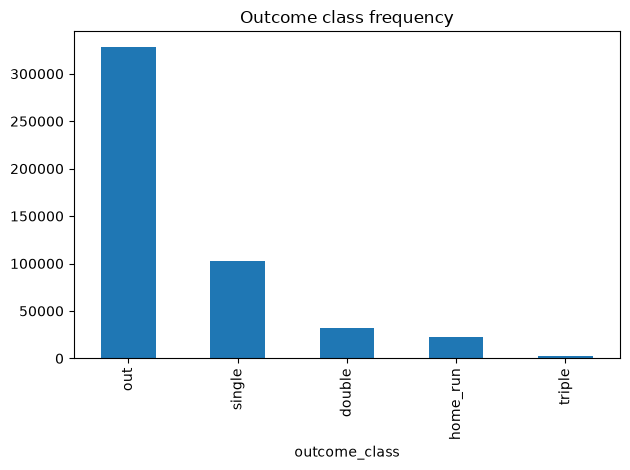

In [8]:
if df is not None:
    import matplotlib.pyplot as plt

    df["outcome_class"].value_counts().plot(kind="bar", title="Outcome class frequency")
    plt.tight_layout()
    plt.show()
else:
    print("Skipped -- no data loaded.")